# Final Project: Demographic Predictors of Wine Spending

**Group Members:** Maksim Strelkov, Darshit Sapkota , Hrishil Patel, Shayan Dhillon


**Date**: 02/04/2026

---

## Research Question

**Which customer demographics and behaviors best predict wine spending?**

## ***Summary***

Investigate:

1. How much children & teens in home affects time since purchase & amount spent

2. Are people of a certain marital status more likely to spend more and often?
    
3. What income group is more likely to spend on wine?

4. Can customers be segmented into distinct groups based on demographics and purchasing behavior using clustering techniques?

5. Can machine learning models (regression and classification) accurately predict wine spending based on customer demographics and behaviors?

**Data Source:** [Customer Personality Analysis](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)

---

# 0. GitHub Repository link

The IPYNB was hosted publically on GitHub with a commit history of everyones contributions here: [Repository](https://github.com/ShayanDhillon/Data200-Final-Customers)



---

# 1. Setup & Data Loading

In [115]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

columns_to_keep = ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines']

df = pd.read_csv("marketing_campaign.csv", sep="\t")
df = df[columns_to_keep]
print("Data shape:", df.shape)


Data shape: (2240, 10)


The dataset has ten columns across thousands of varying customers

Customers

    - ID:             Customer's unique identifier
    - Year_Birth:     Customer's birth year
    - Education:      Customer's education level
    - Marital_Status: Customer's marital status
    - Income:         Customer's yearly household income
    - Kidhome:        Number of children in customer's household
    - Teenhome:       Number of teenagers in customer's household
    - Dt_Customer:    Date of customer's enrollment with the company
    - Recency:        Number of days since customer's last purchase
    - Complain:       1 if the customer complained in the last 2 years, 0 otherwise

Target

    - MntWines:       Amount spent on wine in last 2 years

---

# 2. Data Cleaning

In [116]:
# normal data cleaning and formatting stuff
# finding missing values, duplicates, outliers, etc. and fixing them

# missing values
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0], end="\n\n")

# duplicates
print("Duplicate rows:", df.duplicated().sum(), end="\n\n")

#remove missing values
df = df.dropna()
print("Data shape after dropping missing values:", df.shape, end="\n\n")

Missing values:
Income    24
dtype: int64

Duplicate rows: 0

Data shape after dropping missing values: (2216, 10)



In [117]:
# make objects into categories

print("Non standard data types:")
print(df.select_dtypes(include=['object']).dtypes)

# convert Marital_Status to category
df['Marital_Status'] = df['Marital_Status'].astype('category')

#convert education to ordinal category
edu_order = ['Basic', 'Graduation', '2n Cycle', 'Master', 'PhD']
df['Education'] = pd.Categorical(df['Education'], categories=edu_order, ordered=True)

# convert Dt_Customer to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

df.head(5)

Non standard data types:
Education         str
Marital_Status    str
Dt_Customer       str
dtype: object


C:\Users\Dar\AppData\Local\Temp\ipykernel_8364\26539551.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include=['object']).dtypes)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173


In [118]:
# clean up some categories, what do they really mean?


# make new marital status, changes to single or partnered
def simplify_marital_status(status):
    if status in ['Married', 'Together']:
        return 'Partnered'
    elif status in ['Single', 'Divorced', 'Widow', 'Alone']:
        return 'Single'
    else:
        return 'Other'

df['Marital_Simplified'] = df['Marital_Status'].apply(simplify_marital_status)
df['Marital_Simplified'] = df['Marital_Simplified'].astype('category')
#remove all "others"
df = df[df['Marital_Simplified'] != 'Other'] #removes "absurd" and "yolo" categories


After data cleaning, we are left with the data shape: (2212, 11), and the dataset is now ready for further feature engineering and exploration/analysis!

We made sure all columns are the correct data types (with proper ordering for ordinal variables).

---

# 3. Feature Engineering & Exploration

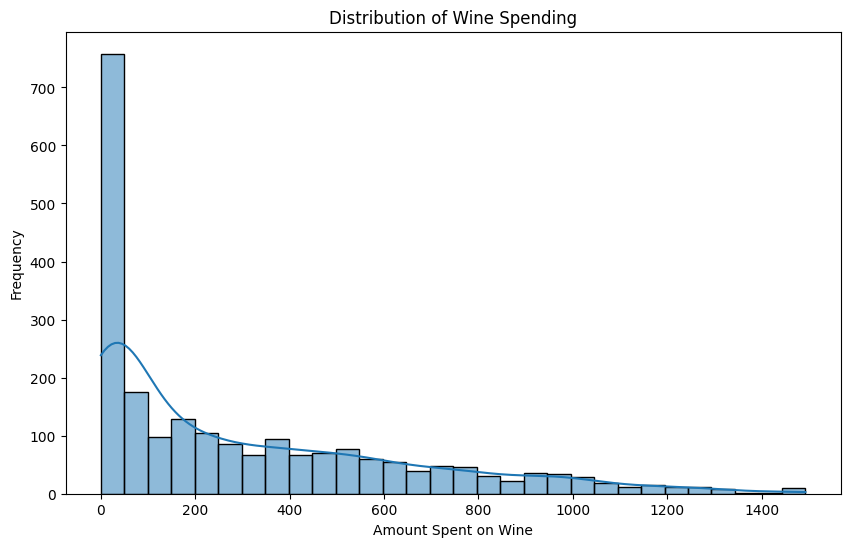

In [119]:
# distribution of wine spending to start off
plt.figure(figsize=(10, 6))
sns.histplot(df['MntWines'], bins=30, kde=True)
plt.title('Distribution of Wine Spending')
plt.xlabel('Amount Spent on Wine')
plt.ylabel('Frequency')
plt.show()



#did this one for u since its not part of the 3 :)

**Interpretation:**

The distribution of wine spending is very right-skewed, most customers spend low amounts on wine, only very few customers are high spenders. As shown by the long tail which extends to large spending amounts, there exists a premium segment of customers that drives a large portion of revenue from wine sales!

Finding commonalities among high spenders will be important for understanding the factors that drive increased spending on wine.


In [ ]:
# do feature engineering

# family types: "No Kids", "Young Kids", "Teenagers", "Both"

# return the family type based on the age of the child in the home
def family_types(type):
    if type["Kidhome"] == 0 and type["Teenhome"] == 0:
        return "No Kids"
    elif type["Kidhome"] > 0 and type["Teenhome"] == 0:
        return "Kid Only"
    elif type["Kidhome"] == 0 and type["Teenhome"] > 0:
        return "Teen Only"
    else:
        return "Both"

# apply the function above as a new column then make sure its a categorical column
df["Family_Type"] = df.apply(family_types, axis=1)
df["Family_Type"] = df["Family_Type"].astype("category")



# Create a new column which separates the incomes into 3 ~equal distinct groups using qcut
df["Income_Group"] = pd.qcut(df["Income"], q=3, labels=['Low', "Middle", "High"])


3.1 How much children & teens in home affects amount spent
    (children, teen and both, make new feature on family type)

C:\Users\Dar\AppData\Local\Temp\ipykernel_8364\4016353529.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Family_Type", y= "MntWines", data=df, order=["No Kids", "Kid Only", "Teen Only", "Both"], density_norm="width",cut=0, palette="Set2")


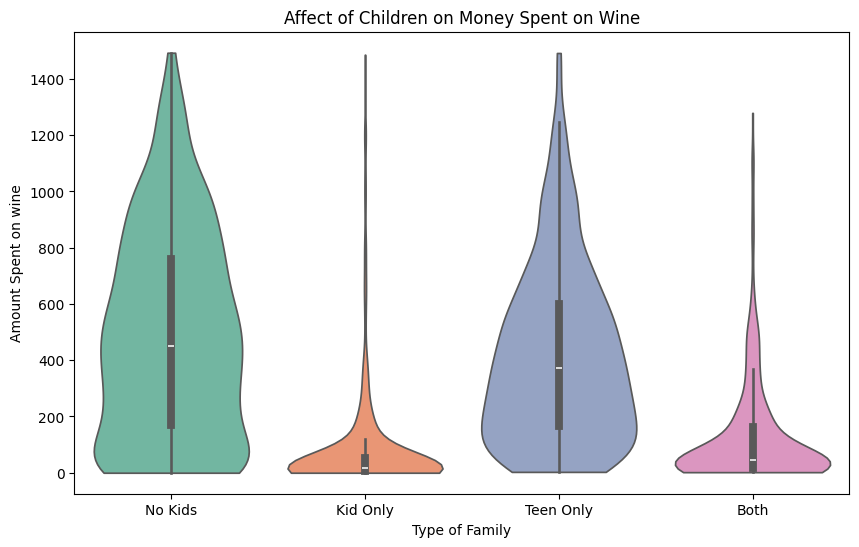

In [121]:
plt.figure(figsize=(10, 6))
sns.violinplot(x="Family_Type", y= "MntWines", data=df, order=["No Kids", "Kid Only", "Teen Only", "Both"], density_norm="width",cut=0, palette="Set2")
plt.title("Affect of Children on Money Spent on Wine")
plt.xlabel("Type of Family")
plt.ylabel("Amount Spent on wine")
plt.show()

**Interpretation:**

From this data we can tell that there is a significant disparity between what seems to be 2 groups of data. The two sets being "having a young child" and "not having a young child". Customers with young children according to the data are much less likely to spend much on wine as opposed to customers without young children. Those without young children spend more on average and on outliers when compared to those with young children.

3.2 Are people of a certain marital status more likely to spend more and often?

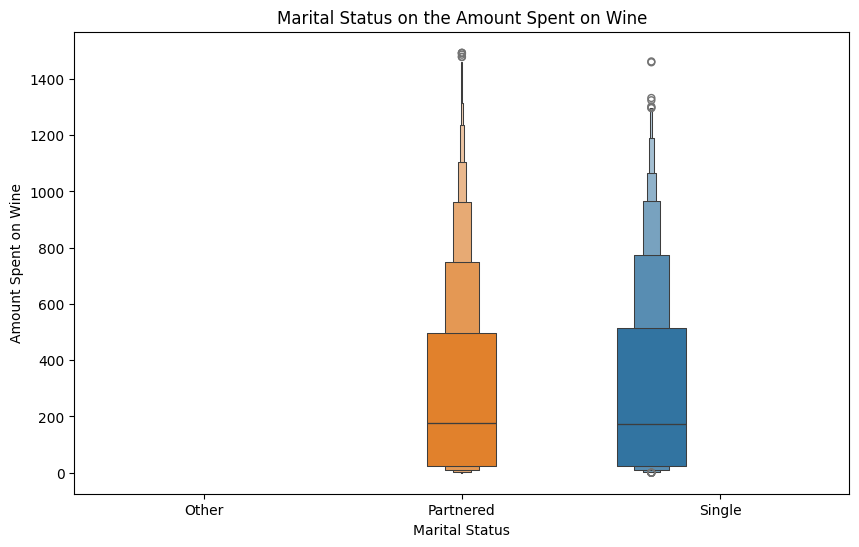

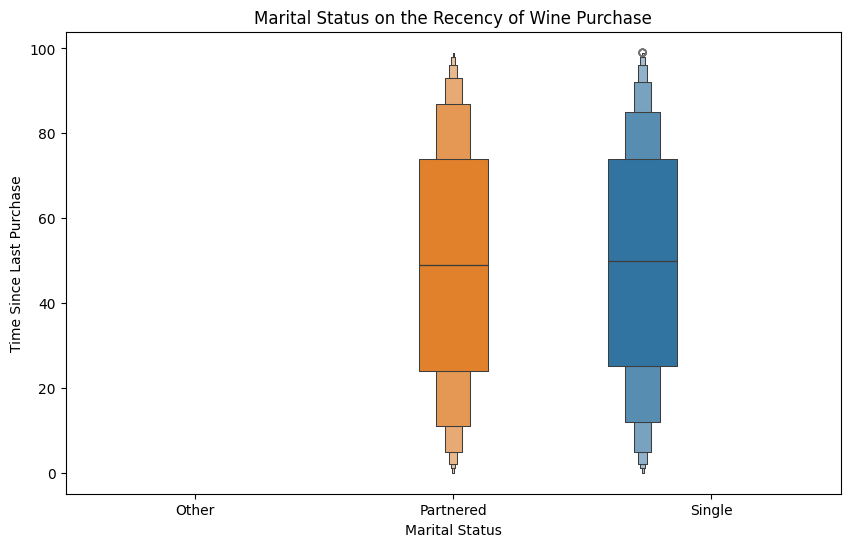

In [159]:

plt.figure(figsize=(10,6))
sns.boxenplot(data=df, x="Marital_Simplified", y="MntWines", hue="Marital_Simplified")
plt.title("Marital Status on the Amount Spent on Wine")
plt.ylabel("Amount Spent on Wine")
plt.xlabel("Marital Status")
plt.show()

plt.figure(figsize=(10,6))
sns.boxenplot(data=df, x="Marital_Simplified", y="Recency", hue="Marital_Simplified")
plt.title("Marital Status on the Recency of Wine Purchase")
plt.xlabel("Marital Status")
plt.ylabel("Time Since Last Purchase")
plt.show()

**Interpretation:**

There was not a very large sample of 'Other' therefore it is not visible on the plot.

The plotting of this dataset shows no clean indication that the maritial status of the customer affects the Amount Spent nor the Days since purchase. Partnered individuals are very minimally more inclined to spend more on wine but this different is small enough to be a sampling limitation. The Recency of purchase has no visible differences in the different categories.


3.3 What income group is more likely to spend on wine?

C:\Users\Dar\AppData\Local\Temp\ipykernel_8364\820095158.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y="Income_Group", x="MntWines", order=["Low", "Middle", "High"], palette="Set2")


Income_Group
Low       738
Middle    737
High      737
Name: count, dtype: int64

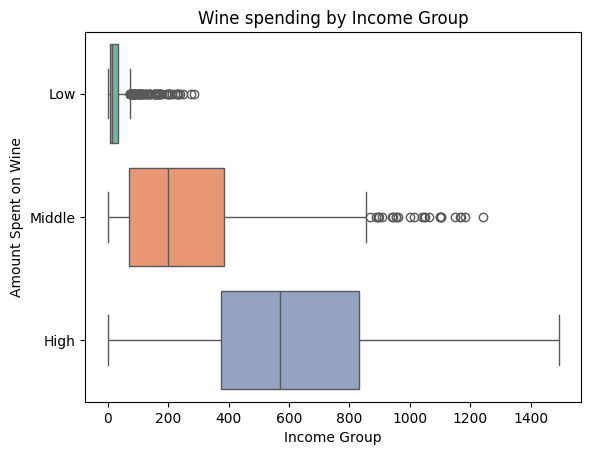

In [95]:
sns.boxplot(data=df, y="Income_Group", x="MntWines", order=["Low", "Middle", "High"], palette="Set2")

plt.title("Wine spending by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Amount Spent on Wine")

df["Income_Group"].value_counts()


**Interpretation:**

The plot expresses a positive correlation between income group and the amount spent on wines, those in the low income group are spending very little on wine other than outliers which spend in the interquartile range of the middle income group. Through this data and the value count extracted of each category, we can understand that middle and high income groups are the higher spenders when compared to low income while also having around the same number of unique IDs.  


---

# 4. Modelling

## USE Regularization techniques, with appropriate interpretations (especially regarding the bias-variance tradeoff)

Setup

In [ ]:
#  cross validation, test train set etc

4.1 Clustering

In [ ]:
#CLUSTERING FIRST, make clusters as a feature and use in model

**Interpretation:**

4.2 Model Building

In [ ]:
#Regression and Classification

In [ ]:
# convergence plot

**Interpretation:**

In [ ]:
# final results plot

**Interpretation:**

---


# 5. Conclusion


Final conclusion